In [79]:
results.to_csv("../data/model_comparison_results.csv", index=False)


In [78]:
import streamlit as st

st.title("Crop Yield Prediction")

rain = st.number_input("Rainfall (mm)")
temp = st.number_input("Temperature (°C)")
pest = st.number_input("Pesticides")

if st.button("Predict"):
    result = predict_crop_yield(rain, temp, pest)
    st.success(f"Predicted Yield: {result}")


2026-01-11 01:20:29.228 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-11 01:20:29.464 
  command:

    streamlit run c:\Users\bhavy\crop-production-forecasting\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-01-11 01:20:29.465 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-11 01:20:29.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-11 01:20:29.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-11 01:20:29.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-11 01:20:29.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-11 01:20:29.468

In [77]:
pip install streamlit


  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached charset_normalizer-3.4.4-cp314-cp314-win_amd64.whl.metadata (38 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached markupsafe-3.0.3-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/9.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.0 MB 7.1 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.0 MB 8.6 MB/s eta 0:00:01
   ----------------------- ---------------- 5.2/9.0 MB 9.6 MB/s eta 0:00:01
   ------------------------------ --------- 6.8/9.0 MB 9.1 MB/s 

In [76]:
def predict_crop_yield(rainfall, temperature, pesticides):
    data = pd.DataFrame(
        [[rainfall, temperature, pesticides]],
        columns=X_train.columns
    )
    return best_xgb.predict(data)[0]


In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


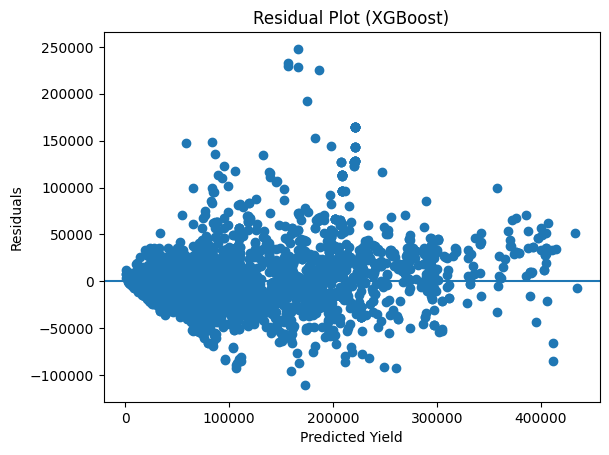

In [74]:
plt.figure()
plt.scatter(y_pred_xgb, y_test - y_pred_xgb)
plt.axhline(0)
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.title("Residual Plot (XGBoost)")
plt.show()


In [73]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2"
)

grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_


In [72]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb, X_train, y_train,
    cv=5,
    scoring="r2"
)

cv_scores.mean()


np.float64(0.9195759654045105)

In [71]:
def predict_yield(rainfall, temperature, pesticides):
    model = joblib.load("models/best_crop_yield_model.pkl")
    data = pd.DataFrame([[rainfall, temperature, pesticides]],
                        columns=["Rainfall", "Temperature", "Pesticides"])
    return model.predict(data)


In [70]:
import joblib
joblib.dump(xgb, "../models/best_crop_yield_model.pkl")


['../models/best_crop_yield_model.pkl']

In [69]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance


,Feature,Importance
106,Item_Potatoes,0.144272
110,Item_Sweet potatoes,0.049395
112,Item_Yams,0.042359
22,Area_Canada,0.039475
8,Area_Australia,0.035277
...,...,...
70,Area_Nepal,0.000000
96,Area_Tunisia,0.000000
89,Area_Sri Lanka,0.000000
83,Area_Rwanda,0.000000


In [68]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance


,Feature,Importance
106,Item_Potatoes,0.371347
107,"Item_Rice, paddy",0.072698
110,Item_Sweet potatoes,0.067558
3,Pesticides,0.059373
45,Area_India,0.058153
...,...,...
54,Area_Latvia,0.000017
96,Area_Tunisia,0.000015
33,Area_Estonia,0.000007
66,Area_Montenegro,0.000004


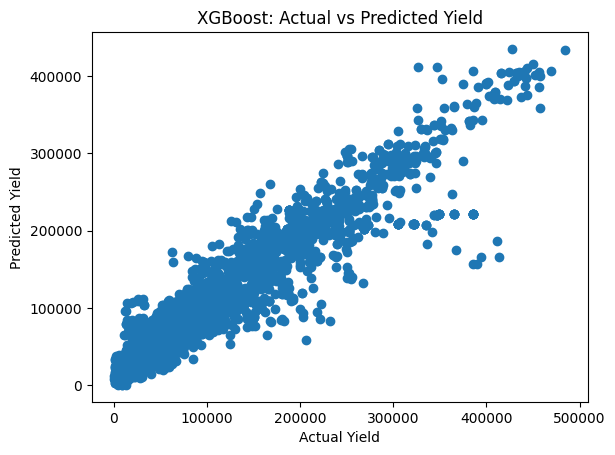

In [67]:
plt.figure()
plt.scatter(y_test, y_pred_xgb)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("XGBoost: Actual vs Predicted Yield")
plt.show()


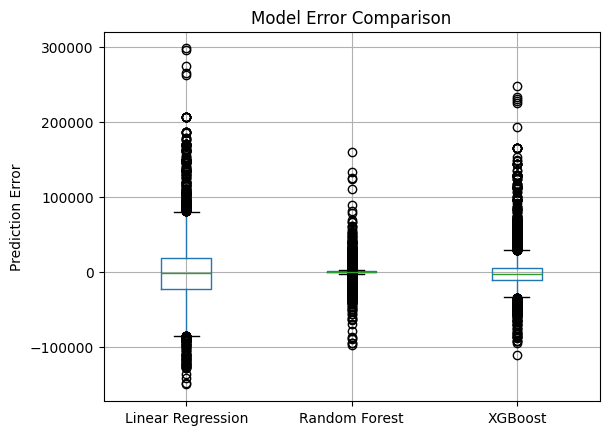

In [66]:
errors_df = pd.DataFrame({
    "Linear Regression": y_test - y_pred,
    "Random Forest": y_test - y_pred_rf,
    "XGBoost": y_test - y_pred_xgb
})

import matplotlib.pyplot as plt

plt.figure()
errors_df.boxplot()
plt.ylabel("Prediction Error")
plt.title("Model Error Comparison")
plt.show()


In [65]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MSE": [lr_mse, rf_mse, xgb_mse],
    "MAE": [lr_mae, rf_mae, xgb_mae],
    "R2 Score": [lr_r2, rf_r2, xgb_r2]
})

results


,Model,MSE,MAE,R2 Score
0,Linear Regression,1.847709e+09,30010.201300,0.749165
1,Random Forest,8.660622e+07,3345.523663,0.988243
2,XGBoost,6.257236e+08,14873.787109,0.915055


In [64]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Linear Regression metrics
lr_mse = mean_squared_error(y_test, y_pred)
lr_mae = mean_absolute_error(y_test, y_pred)
lr_r2  = r2_score(y_test, y_pred)

# Random Forest metrics
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2  = r2_score(y_test, y_pred_rf)

# XGBoost metrics
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2  = r2_score(y_test, y_pred_xgb)


In [63]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MSE": [lr_mse, rf_mse, xgb_mse],
    "MAE": [lr_mae, rf_mae, xgb_mae],
    "R2 Score": [lr_r2, rf_r2, xgb_r2]
})

results


NameError: name 'lr_mse' is not defined

In [62]:
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2  = r2_score(y_test, y_pred_xgb)

xgb_mse, xgb_mae, xgb_r2


(625723648.0, 14873.787109375, 0.9150551557540894)

In [61]:
y_pred_xgb = xgb.predict(X_test)


In [60]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [59]:
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2  = r2_score(y_test, y_pred_rf)

rf_mse, rf_mae, rf_r2


(86606223.19145161, 3345.5236628318585, 0.9882428084915093)

In [58]:
y_pred_rf = rf.predict(X_test)


In [57]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [56]:
from xgboost import XGBRegressor


In [55]:
pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 3.7 MB/s eta 0:00:20
    --------------------------------------- 1.0/72.0 MB 2.8 MB/s eta 0:00:26
   - -------------------------------------- 1.8/72.0 MB 2.8 MB/s eta 0:00:25
   - -------------------------------------- 2.1/72.0 MB 2.8 MB/s eta 0:00:26
   - -------------------------------------- 2.6/72.0 MB 2.7 MB/s eta 0:00:27
   - -------------------------------------- 3.1/72.0 MB 2.6 MB/s eta 0:00:27
   - -------------------------------------- 3.4/72.0 MB 2.6 MB/s eta 0:00:27
   -- ------------------------------------- 3.9/72.0 MB 2.5 MB/s eta 0:00:28
   -- ------------------------------------- 4.5/72.0 MB 2.4 MB/s eta 0:00:29
   -- ------------------------------------- 4.7/72.0 MB 2.3 MB/s eta 0:00:29
   -- ------------------------------------- 5.2/72.0 MB 2.3 MB/s eta 0:00:30
   --- ------

In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [53]:
loaded_model = joblib.load("../models/crop_yield_model.pkl")
loaded_model


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [52]:
import joblib
joblib.dump(lr, "../models/crop_yield_model.pkl")


['../models/crop_yield_model.pkl']

In [51]:
final_df.to_csv("../data/processed_crop_data.csv", index=False)


In [50]:
coeff_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
})

coeff_df


,Feature,Coefficient
0,Year,1112.464616
1,Rainfall,3.841100
2,Avg_Temp,-35.219886
3,Pesticides,0.025873
4,Area_Algeria,2339.045518
...,...,...
108,Item_Sorghum,-139527.383929
109,Item_Soybeans,-150378.900411
110,Item_Sweet potatoes,-42578.242888
111,Item_Wheat,-143207.468660


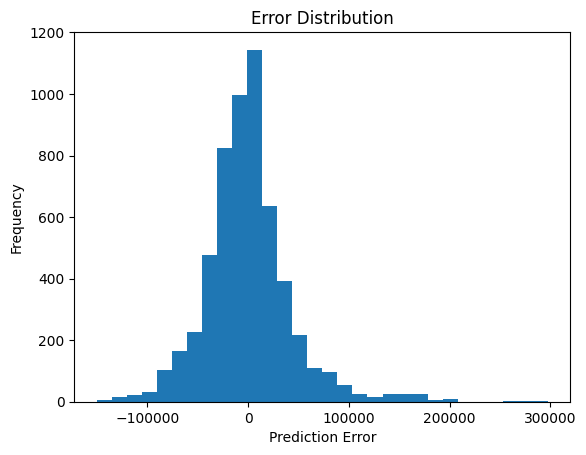

In [49]:
errors = y_test - y_pred

plt.figure()
plt.hist(errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.show()


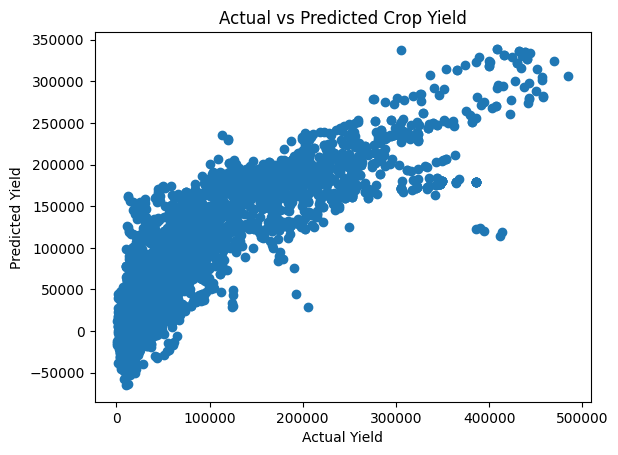

In [48]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield")
plt.show()


In [47]:
loaded_model = joblib.load("../models/crop_yield_model.pkl")
loaded_model.predict(X_test.head())


array([-34539.05019229,  28830.26548012, 130925.40390326, 102160.45546521,
        32053.05154542])

In [46]:
import joblib

joblib.dump(lr, "../models/crop_yield_model.pkl")


['../models/crop_yield_model.pkl']

In [44]:
coeff_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
})

coeff_df


,Feature,Coefficient
0,Year,1112.464616
1,Rainfall,3.841100
2,Avg_Temp,-35.219886
3,Pesticides,0.025873
4,Area_Algeria,2339.045518
...,...,...
108,Item_Sorghum,-139527.383929
109,Item_Soybeans,-150378.900411
110,Item_Sweet potatoes,-42578.242888
111,Item_Wheat,-143207.468660


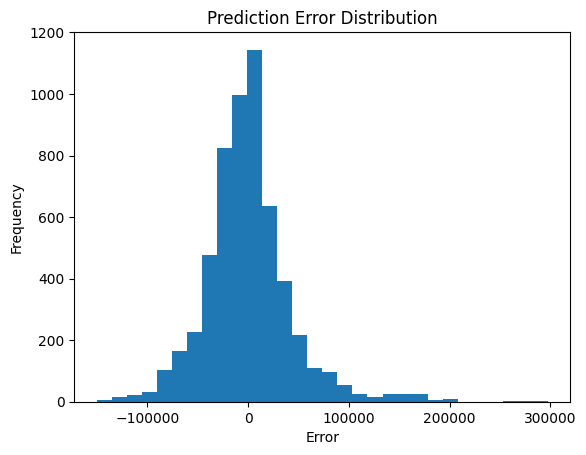

In [43]:
errors = y_test - y_pred

plt.figure()
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()


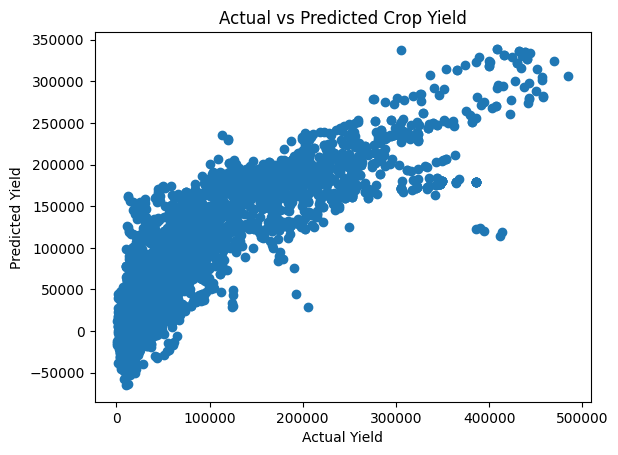

In [42]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield")
plt.show()


In [41]:
final_df.to_csv("../data/processed_crop_data.csv", index=False)


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = lr.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))


MAE : 30010.201299679742
RMSE: 42984.98435744103
R²  : 0.7491650558581819


In [39]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)


In [37]:
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test  = X_test.apply(pd.to_numeric, errors="coerce")


In [35]:
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)


In [34]:
X_train.dtypes.value_counts()


bool       109
float64      2
object       1
int64        1
Name: count, dtype: int64

In [33]:
X_train.isnull().sum().sort_values(ascending=False).head(10)


Year              0
Rainfall          0
Avg_Temp          0
Pesticides        0
Area_Algeria      0
Area_Angola       0
Area_Argentina    0
Area_Armenia      0
Area_Australia    0
Area_Austria      0
dtype: int64

In [32]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)


ValueError: could not convert string to float: '..'

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [30]:
X = final_df.drop("Yield", axis=1)
y = final_df["Yield"]

print(X.shape, y.shape)


(28248, 113) (28248,)


In [29]:
import pandas as pd

final_df = pd.read_csv("../data/processed_crop_data.csv")
final_df.head()


C:\Users\bhavy\AppData\Local\Temp\ipykernel_23828\1140979631.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  final_df = pd.read_csv("../data/processed_crop_data.csv")


,Year,Rainfall,Avg_Temp,Pesticides,Yield,Area_Algeria,Area_Angola,Area_Argentina,Area_Armenia,Area_Australia,...,Area_Zimbabwe,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,1990,1485,16.37,121.0,36613,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,1991,1485,15.36,121.0,29068,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,1992,1485,16.06,121.0,24876,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,1993,1485,16.05,121.0,24185,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,1994,1485,16.96,201.0,25848,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [28]:
final_df.to_csv("../data/processed_crop_data.csv", index=False)


In [27]:
final_df = pd.get_dummies(final_df, columns=["Area", "Item"], drop_first=True)


In [26]:
final_df = merged_df[
    ["Area", "Item", "Year",
     "Rainfall",
     "Avg_Temp",
     "Pesticides",
     "Yield"]
]

final_df.head()


,Area,Item,Year,Rainfall,Avg_Temp,Pesticides,Yield
0,Albania,Maize,1990,1485,16.37,121.0,36613
1,Albania,Maize,1991,1485,15.36,121.0,29068
2,Albania,Maize,1992,1485,16.06,121.0,24876
3,Albania,Maize,1993,1485,16.05,121.0,24185
4,Albania,Maize,1994,1485,16.96,201.0,25848


In [25]:
merged_df = yield_df.merge(rain_df, on=["Area", "Year"], how="inner")
merged_df = merged_df.merge(temp_df, on=["Area", "Year"], how="inner")
merged_df = merged_df.merge(pest_df, on=["Area", "Year"], how="inner")

merged_df.head()


,Area,Item,Year,Yield,Rainfall,Avg_Temp,Pesticides
0,Albania,Maize,1990,36613,1485,16.37,121.0
1,Albania,Maize,1991,29068,1485,15.36,121.0
2,Albania,Maize,1992,24876,1485,16.06,121.0
3,Albania,Maize,1993,24185,1485,16.05,121.0
4,Albania,Maize,1994,25848,1485,16.96,201.0


In [24]:
temp_df["Avg_Temp"] = temp_df["Avg_Temp"].fillna(temp_df["Avg_Temp"].mean())
temp_df.head()


,Year,Area,Avg_Temp
0,1849,Côte D'Ivoire,25.580000
1,1850,Côte D'Ivoire,25.520000
2,1851,Côte D'Ivoire,25.670000
3,1852,Côte D'Ivoire,16.183876
4,1853,Côte D'Ivoire,16.183876


In [23]:
temp_df = temp_df.rename(columns={
    "country": "Area",
    "year": "Year",
    "avg_temp": "Avg_Temp"
})


In [22]:
list(temp_df.columns)


['year', 'country', 'avg_temp']

In [21]:
temp_df = pd.read_csv("../data/temp.csv")
temp_df.head()


,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN


In [20]:
pest_df = pest_df.rename(columns={"Value": "Pesticides"})
pest_df = pest_df[["Area", "Year", "Pesticides"]]
pest_df.head()


,Area,Year,Pesticides
0,Albania,1990,121.0
1,Albania,1991,121.0
2,Albania,1992,121.0
3,Albania,1993,121.0
4,Albania,1994,201.0


In [19]:
list(pest_df.columns)


['Domain', 'Area', 'Element', 'Item', 'Year', 'Unit', 'Value']

In [18]:
pest_df = pd.read_csv("../data/pesticides.csv")
pest_df.head()


,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


In [17]:
yield_df.head()


,Area,Item,Year,Yield
0,Afghanistan,Maize,1961,14000
1,Afghanistan,Maize,1962,14000
2,Afghanistan,Maize,1963,14260
3,Afghanistan,Maize,1964,14257
4,Afghanistan,Maize,1965,14400


In [16]:
yield_df = yield_df[["Area", "Item", "Year", "Yield"]]
yield_df.head()


,Area,Item,Year,Yield
0,Afghanistan,Maize,1961,14000
1,Afghanistan,Maize,1962,14000
2,Afghanistan,Maize,1963,14260
3,Afghanistan,Maize,1964,14257
4,Afghanistan,Maize,1965,14400


In [15]:
yield_df = yield_df.rename(columns={"Value": "Yield"})


In [14]:
list(yield_df.columns)


['Domain Code',
 'Domain',
 'Area Code',
 'Area',
 'Element Code',
 'Element',
 'Item Code',
 'Item',
 'Year Code',
 'Year',
 'Unit',
 'Value']

In [13]:
yield_df = pd.read_csv("../data/yield.csv")
yield_df.head()


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400


In [11]:
rain_df = rain_df[["Area", "Year", "Rainfall"]]
rain_df.head()


,Area,Year,Rainfall
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327


In [10]:
list(rain_df.columns)


['Area', 'Year', 'Rainfall']

In [9]:
rain_df = rain_df.rename(
    columns={"Average_Rain_Fall_Mm_Per_Year": "Rainfall"}
)


In [8]:
list(rain_df.columns)


['Area', 'Year', 'Rainfall']

In [7]:
rain_df.columns = rain_df.columns.str.strip()
rain_df.columns = rain_df.columns.str.title()


In [6]:
list(rain_df.columns)


[' Area', 'Year', 'Rainfall']

In [4]:
rain_df.columns


Index([' Area', 'Year', 'Rainfall'], dtype='object')

In [3]:
rain_df = rain_df.rename(
    columns={"average_rain_fall_mm_per_year": "Rainfall"}
)


In [2]:
rain_df.columns


Index([' Area', 'Year', 'average_rain_fall_mm_per_year'], dtype='object')

In [1]:
import pandas as pd

rain_df = pd.read_csv("../data/rainfall.csv")
rain_df.head()


,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327


In [15]:
yield_df.rename(columns={"Value": "Yield"}, inplace=True)


In [14]:
print("Yield:", yield_df.columns)
print("Rain :", rain_df.columns)
print("Temp :", temp_df.columns)
print("Pest :", pest_df.columns)


Yield: Index(['Domain Code', 'Domain', 'Area Code', 'Area', 'Element Code', 'Element',
       'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value'],
      dtype='object')
Rain : Index([' Area', 'Year', 'average_rain_fall_mm_per_year'], dtype='object')
Temp : Index(['year', 'country', 'avg_temp'], dtype='object')
Pest : Index(['Domain', 'Area', 'Element', 'Item', 'Year', 'Unit', 'Value'], dtype='object')


In [13]:
import pandas as pd

yield_df = pd.read_csv("../data/yield.csv")
rain_df  = pd.read_csv("../data/rainfall.csv")
temp_df  = pd.read_csv("../data/temp.csv")
pest_df  = pd.read_csv("../data/pesticides.csv")

yield_df.head()


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400


In [12]:
rain_df.columns


Index([' Area', 'Year', 'average_rain_fall_mm_per_year'], dtype='object')

In [10]:
pest_df.rename(columns={"Value": "Pesticides"}, inplace=True)

pest_df = pest_df[["Area", "Year", "Pesticides"]]


In [9]:
yield_df.rename(columns={"Value": "Yield"}, inplace=True)


In [8]:
yield_df = pd.read_csv("../data/yield.csv")
rain_df  = pd.read_csv("../data/rainfall.csv")
pest_df  = pd.read_csv("../data/pesticides.csv")
yield_df.head()
rain_df.head()
pest_df.head()



,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


In [4]:
temp_df = pd.read_csv("../data/temp.csv")
temp_df.head()


,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN


In [2]:
import pandas as pd
print(pd.__version__)


2.3.3


In [1]:
print(X_train.columns.tolist())

NameError: name 'X_train' is not defined

In [2]:
print(X.columns.tolist())

NameError: name 'X' is not defined

In [3]:
import pandas as pd

df = pd.read_csv("data/processed_crop_data.csv")

print(df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed_crop_data.csv'

In [4]:
import pandas as pd

df = pd.read_csv("../data/processed_crop_data.csv")

print(df.columns.tolist())

['Year', 'Rainfall', 'Avg_Temp', 'Pesticides', 'Yield', 'Area_Algeria', 'Area_Angola', 'Area_Argentina', 'Area_Armenia', 'Area_Australia', 'Area_Austria', 'Area_Azerbaijan', 'Area_Bahamas', 'Area_Bahrain', 'Area_Bangladesh', 'Area_Belarus', 'Area_Belgium', 'Area_Botswana', 'Area_Brazil', 'Area_Bulgaria', 'Area_Burkina Faso', 'Area_Burundi', 'Area_Cameroon', 'Area_Canada', 'Area_Central African Republic', 'Area_Chile', 'Area_Colombia', 'Area_Croatia', 'Area_Denmark', 'Area_Dominican Republic', 'Area_Ecuador', 'Area_Egypt', 'Area_El Salvador', 'Area_Eritrea', 'Area_Estonia', 'Area_Finland', 'Area_France', 'Area_Germany', 'Area_Ghana', 'Area_Greece', 'Area_Guatemala', 'Area_Guinea', 'Area_Guyana', 'Area_Haiti', 'Area_Honduras', 'Area_Hungary', 'Area_India', 'Area_Indonesia', 'Area_Iraq', 'Area_Ireland', 'Area_Italy', 'Area_Jamaica', 'Area_Japan', 'Area_Kazakhstan', 'Area_Kenya', 'Area_Latvia', 'Area_Lebanon', 'Area_Lesotho', 'Area_Libya', 'Area_Lithuania', 'Area_Madagascar', 'Area_Malawi'

C:\Users\bhavy\AppData\Local\Temp\ipykernel_30444\4215164465.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed_crop_data.csv")
